# MNIST: Logistic Regression, FFN (PyTorch)

## Libraries and constants

In [1]:
import os
from abc import ABC, abstractmethod

import joblib
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch

#from PIL import Image
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedKFold, cross_validate
from torch import nn, optim
from torch.utils.data import DataLoader, Dataset, Subset  #, random_split
from torchvision import datasets, transforms
from tqdm.notebook import tqdm
from utils import plot_loss_acc_per_ep, seed_everything

In [2]:
# --- CONSTANTS ---
RANDOM_SEED = 42

# --- SEEDING FUNCTIONALITY ---
rng = seed_everything(RANDOM_SEED)

# for num_workers > 0 in PyTorch DataLoader, each worker will inherit the exact same random state from the main process
# This means every worker will generate the exact same "random" data augmentations. We fix this using worker_init_fn
torch_gen = torch.Generator()
torch_gen.manual_seed(RANDOM_SEED)

## Data import

In [3]:
mnist_train_raw = datasets.MNIST(
    root="./data",
    train=True,
    download=True, # download the data if it's not in ./data
)

mnist_test_raw = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
)

# Train/test sizes
print("\nTrain set: ")
print(mnist_train_raw.data.shape)

print("\nTest set: ")
print(mnist_test_raw.data.shape)


Train set: 
torch.Size([60000, 28, 28])

Test set: 
torch.Size([10000, 28, 28])


## Data Overview

In [4]:
img, label = mnist_train_raw[0]

print(f"Image: {img}")
print(f"The label: {label}")

Image: <PIL.Image.Image image mode=L size=28x28 at 0x24A94493C10>
The label: 5


Train images:


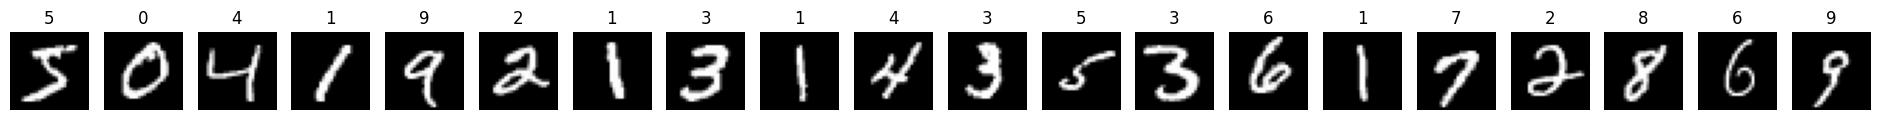

Test images:


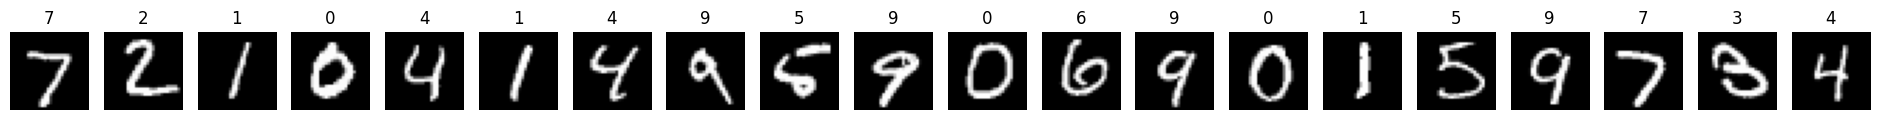

In [5]:
def plot_mnist_images(dataset, num_images: int):
    plt.figure(figsize=(24, 6))
    for i in range(num_images):
        img, label = dataset[i]
        if torch.is_tensor(img):
            img = img.squeeze()      # (1,28,28) -> (28,28)
        plt.subplot(
            1,              # a number of rows to plot on
            num_images,     # a number of columns
            i + 1,          # current position to plot in
        )
        plt.imshow(img, cmap='gray')
        plt.title(label)
        plt.axis('off')
    plt.show()

print("Train images:")
plot_mnist_images(mnist_train_raw, 20)

print("Test images:")
plot_mnist_images(mnist_test_raw, 20)

Each image represents a grayscale 28x28 picture of a digit (0-9), each object is already a PIL image.

### Class balance

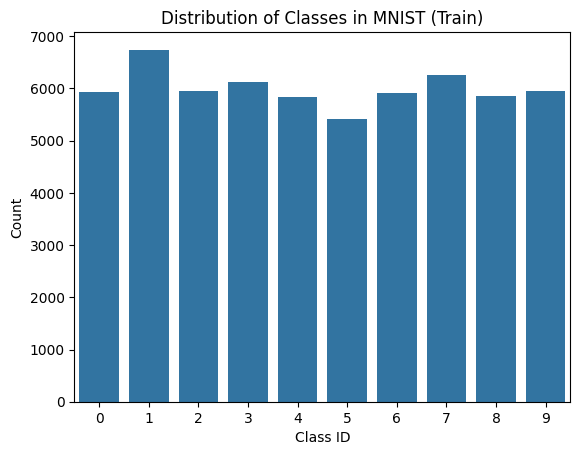

In [6]:
train_labels = mnist_train_raw.targets

sns.countplot(x=train_labels)
plt.title("Distribution of Classes in MNIST (Train)")
plt.xlabel("Class ID")
plt.ylabel("Count")
plt.show()

The train set is relatively evenly distributed. No imbalance concerns.

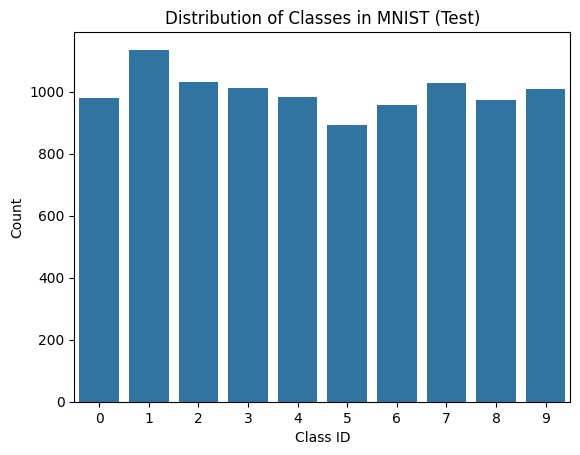

In [7]:
test_labels = mnist_test_raw.targets

sns.countplot(x=test_labels)
plt.title("Distribution of Classes in MNIST (Test)")
plt.xlabel("Class ID")
plt.ylabel("Count")
plt.show()

The test set is also even, the classification report will be accurate.

### Data representation

Although MNIST is a part of the torchvision's datasets, we are following the usual convention and encapsulate it into a separate class. Each item is a pair of (image, label).

In [8]:
class MNISTDataset(Dataset):
    def __init__(self, data, targets, transform=None, transform_target=None):
        self.data = data
        self.targets = targets
        self.transform = transform
        self.transform_target = transform_target

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img, target = self.data[idx], int(self.targets[idx])

        # MNIST dataset is already PIL
        # img = Image.fromarray(img.numpy(), mode="L")               # to PIL grayscale image
        if self.transform is not None:
            img = self.transform(img)

        if self.transform_target is not None:
            target = self.transform_target(target)
        return img, target

In [9]:
train_images = mnist_train_raw.data.numpy()
train_targets = mnist_train_raw.targets.numpy()

test_images = mnist_test_raw.data.numpy()
test_targets = mnist_test_raw.targets.numpy()

## Data normalization

As always, for the sake of speeding up the convergence, stabilize GD, eliminating brightness  biases, we normalize pictures into [0,1] and std=1, mean=0.

In order to do that, we need the whole dataset, which in this case is not huge and fits RAM. But the best practice is to import it in batches in case there are too many samples.

While importing, we're summing the sums and elements to later calculate final dataset's mean and std to use them for z-normalization.

In [10]:
mnist_train_raw_images = mnist_train_raw.data.numpy()
mnist_train_raw_normalized = MNISTDataset(data=mnist_train_raw_images, targets=train_targets, transform=transforms.ToTensor())

loader = DataLoader(mnist_train_raw_normalized, batch_size=1024)   # dataset with ToTensor() only, no Normalize
n = 0; s = 0.0; ss = 0.0
for x, _ in loader:
    s  += x.sum().item()
    ss += (x**2).sum().item()
    n  += x.numel()
mean_ds = s / n
std_ds  = (ss/n - mean_ds**2) ** 0.5

## Data split

In [11]:
transformations_from_raw = transforms.Compose([
    transforms.ToTensor(),                                      # converts [0,255] -> [0,1]
    transforms.Normalize(mean=(mean_ds,), std=(std_ds,)),       # -> mean 0, std 1
])

# ----- Tain-test split in case we need a validation set. We use cross-validation, so we don't -----
# full_train_dataset = MNISTDataset(
#     data=train_images,
#     targets=train_targets,
#     transform=transformations_from_raw,
# )

# # Split train into train/validation (85/15)
# train_size = int(0.85 * len(train_images))
# val_size = len(full_train_dataset) - train_size

# # Randomly split and shuffle the data
# mnist_train, mnist_valid = random_split(
#     dataset=full_train_dataset,
#     lengths=[train_size, val_size],
#     generator=torch.Generator().manual_seed(RANDOM_SEED),
# )

mnist_train = MNISTDataset(
    data=train_images,
    targets=train_targets,
    transform=transformations_from_raw,
)

mnist_test = MNISTDataset(
    data=test_images,
    targets=test_targets,
    transform=transformations_from_raw,
)

Confirming everything's intact.

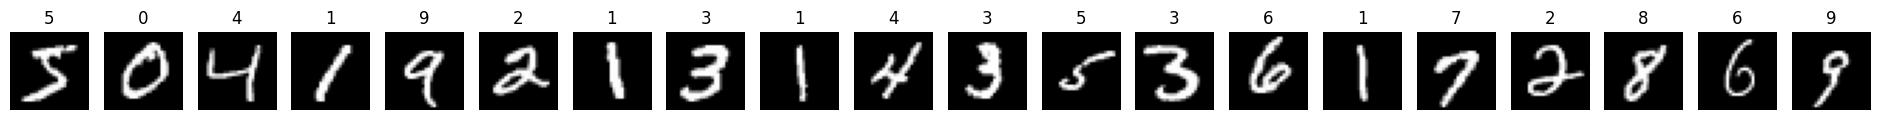

In [12]:
plot_mnist_images(mnist_train, 20)

In [13]:
print(f"Train: {len(mnist_train)}, Test: {len(mnist_test)}")

Train: 60000, Test: 10000


## Creating and testing loaders

In [14]:
train_loader = DataLoader(
    dataset=mnist_train,
    batch_size=8,
    shuffle=True,
    generator=torch_gen,            # dedicated RNG for reproducible shuffle order
)

# val_loader = DataLoader(
#     mnist_valid,
#     batch_size=8,
#     shuffle=False,                # do not shuffle validation
# )

test_loader = DataLoader(
    dataset=mnist_test,
    batch_size=8,
    shuffle=False,                  # do not shuffle test
)

In [15]:
# DataLoaders testing
images_batch, targets_batch = next(iter(train_loader))

print("Images batch shape :", images_batch.shape)
print("Targets batch shape:", targets_batch.shape)
print("Images data type   :", images_batch.dtype)
print("Targets data type  :", targets_batch.dtype)
print("Targets in batch   :", targets_batch)

Images batch shape : torch.Size([8, 1, 28, 28])
Targets batch shape: torch.Size([8])
Images data type   : torch.float32
Targets data type  : torch.int64
Targets in batch   : tensor([8, 1, 4, 6, 3, 4, 0, 2])


## EDA

### Outlier detection

`IsolationForest` is best for high-dimensional, large, non-Gaussian multivariate data. We don't know how smudgy, blurred or well-written the images are. We are going to flag 1% of the easiest to isolate points, then plot them for assessment.

In [16]:
# (60000, 28, 28) -> (60000, 784)
# transformation isn't applied here, but the forest doesn't need it anyway
train_images_2d = train_images.reshape(-1, 784)

print(f"mnist_train_array_2d.shape = {train_images_2d.shape}")

mnist_train_array_2d.shape = (60000, 784)


In [17]:
# ---------- STEP 1: Fit ----------
iso = IsolationForest(
    n_estimators=500,           # number of random trees
    contamination=0.01,         # expect ~1% anomalies
    max_samples='auto',         # subsample size per tree
    random_state=RANDOM_SEED,
)

iso.fit(train_images_2d)

,n_estimators,500
,max_samples,'auto'
,contamination,0.01
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


In [18]:
# ---------- STEP 2: Predict (-1 = anomaly, 1 = normal) ----------
flags = iso.predict(train_images_2d)
anomaly_mask = flags == -1
print(f"Train anomalies flagged: {anomaly_mask.sum()}")

Train anomalies flagged: 600


In [19]:
# ---------- STEP 3: Get top 5 continuous anomaly scores for ranking ----------
# Lower score = more anomalous
anomaly_score = iso.score_samples(train_images_2d)
print("Top 5 lowest (most anomalous) scores:", sorted(anomaly_score)[:5])

Top 5 lowest (most anomalous) scores: [-0.6489152565601162, -0.6395654856434693, -0.6321896152658757, -0.6289864895689281, -0.6287789506769456]


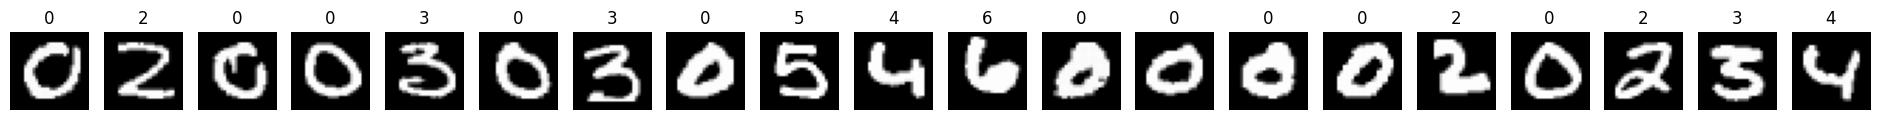

In [20]:
# ---------- STEP 4: See the flagged images ----------
outlier_idx = np.where(flags == -1)[0]
outliers_mnist_train = [mnist_train_raw[idx] for idx in outlier_idx]

plot_mnist_images(outliers_mnist_train, 20)

All characters are recognizable, no side objects (to confirm it, we'd need more data, like classifying it with pre-trained resnet to confirm it's not a vehicle let's say OR we can perform Acceptance Sampling to sample enough to tell that with a 95% chance there are no side images in the dataset) or noisy backgrounds, even in the worst-flagged images. No outliers present.

## Model and training OOP

We are going to utilize Logistic Regression as a simplest classifier as a baseline to compare against a basic FFN.

In [21]:
class MnistClassifierInterface(ABC):
    """Interface that represents each classifier."""

    @abstractmethod
    def train(self) -> dict:
        """Assesses the model using cross-validation, returns logs with metrics / losses on train / validation."""

    @abstractmethod
    def final_fit(self):
      """Final train, fits the model to the training data, saves in self.model."""

    @abstractmethod
    def predict(self, X: np.ndarray, y_true: np.ndarray = None) -> np.ndarray:
        """Predicts X with the trained model, returns y_hat, y."""

In [22]:
class LogisticRegressionModel(MnistClassifierInterface):
    """Logistic Regression classifier class."""

    def __init__(self, train_dataset, max_iter: int = 100, batch_size=64, random_state=42, n_jobs: int | None = None, verbose: int = 0):
        if n_jobs is None:
            n_jobs = os.cpu_count() or 1 # Fallback to 1 if cpu_count() returns None

        self.model = LogisticRegression(max_iter=max_iter,
                                        random_state=random_state,
                                        n_jobs=n_jobs,
                                        verbose=verbose)
        self.train_dataset = train_dataset
        self.batch_size = batch_size
        self.random_state = random_state
        self.n_jobs = n_jobs
        self.verbose = verbose

    def train(self):
        """Trains Logistic Regression on the full training dataset."""
        # --- Define Data Loaders ---
        train_loader = DataLoader(
            self.train_dataset,
            batch_size=self.batch_size,
            shuffle=False,                   # no need to shuffle, sklearn doesn't care
            num_workers=2,
            drop_last=False,                 # no need to discard uneven batches, there's no BatchNorm here
        )

        # 2. --- Extract Train Data (flatten into 2D train data for sklearn) ---
        X_train, y_train = [], []
        print("Extracting training data...")
        for images, labels in train_loader:
            X_train.extend(images.numpy().reshape(images.shape[0], -1)) # (batch_size, 1, 28, 28) -> (batch_size, 1*28*28)
            y_train.extend(labels.numpy())
        X_train = np.array(X_train)
        y_train = np.array(y_train)

        # 3. --- CROSS-VALIDATION ---
        print("\n--- Running 5-Fold Cross-Validation ---")
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=self.random_state)

        cv_results = cross_validate(
            self.model, X_train, y_train,
            cv=cv,
            scoring=["accuracy", "f1_macro"],
            return_train_score=True,
            n_jobs=self.n_jobs,
            verbose=self.verbose,
        )

        if self.verbose:
            print(f"CV Train Accuracy: {cv_results['train_accuracy'].mean():.4f} ± {cv_results['train_accuracy'].std():.4f}")
            print(f"CV Train F1-Macro: {cv_results['train_f1_macro'].mean():.4f} ± {cv_results['train_f1_macro'].std():.4f}")
            print(f"CV Val Accuracy:   {cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}")
            print(f"CV Val F1-Macro:   {cv_results['test_f1_macro'].mean():.4f} ± {cv_results['test_f1_macro'].std():.4f}\n")


        logs = {
            "cv_train_accuracy_mean": cv_results['train_accuracy'].mean(),
            "cv_train_f1_mean": cv_results['train_f1_macro'].mean(),
            "cv_test": cv_results['test_accuracy'].mean(),
            "cv_test_f1_mean": cv_results['test_f1_macro'].mean(),
        }

        return logs

    def final_fit(self):
      # 4. --- Final Fit ---
      X_train, y_train = [], []
      print("Extracting training data...")
      for images, labels in train_loader:
          X_train.extend(images.numpy().reshape(images.shape[0], -1)) # (batch_size, 1, 28, 28) -> (batch_size, 1*28*28)
          y_train.extend(labels.numpy())
      X_train = np.array(X_train)
      y_train = np.array(y_train)

      print("--- Fitting Final Model on Full Train Set ---")
      self.model.fit(X_train, y_train)

      return self.model

    def predict(self, dataset) -> np.ndarray:
        """Predict labels for MNIST images."""
        loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=False)
        X, y = [], []
        for images, labels in loader:
            X.extend(images.numpy().reshape(images.shape[0], -1))
            y.extend(labels.numpy())
        X = np.array(X)
        y = np.array(y)

        preds = self.model.predict(X)
        return preds, y

In [23]:
class FeedForwardClassifierModel(MnistClassifierInterface):
    """Feed Forward Neural Network classifier class."""

    def __init__(self, train_dataset, batch_size: int, epochs: int, criterion: nn.Module = nn.CrossEntropyLoss(),
                 optimizer: optim.Optimizer = optim.Adam, optim_kwargs=None,
                 cv_folds: int = 5, random_state=42, verbose: int = 0, device: str | None = None):

        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Device - {self.device}")

        # storing the architecture, not a single model - CV needs a fresh one per fold
        self._build_model = lambda: nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )
        self.model = self._build_model().to(self.device)
        print("Number of trainable parameters -", sum(p.numel() for p in self.model.parameters() if p.requires_grad))

        self.train_dataset = train_dataset
        self.batch_size = batch_size
        self.epochs = epochs
        self.optimizer = optimizer
        self.optim_kwargs = optim_kwargs or {"lr": 1e-3}
        self.criterion = criterion
        self.cv_folds = cv_folds
        self.random_state = random_state
        self.verbose = verbose
        # to control whether the model is trained
        self.fitted = False

    def _evaluate_loader(self, model, loader):
        """Helper to compute accuracy, macro-f1 and loss for a given batch (given via loader) and a given model."""
        model.eval()
        all_preds, all_labels = [], []
        loss_val = 0.0

        with torch.no_grad():
            for X, y in loader:
                X, y = X.to(self.device), y.to(self.device)
                logits = model(X)
                loss = self.criterion(logits, y)
                # the average loss per sample in this batch
                loss_val += loss.item()         # .item() to extract a scalar itself from a huge object keeping track of all gradient operations
                all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy()) # return the first index of the highest value across dim=1 (horizontally, i.e., for each sample), this is our class (0-9)
                all_labels.extend(y.cpu().numpy())

        # average loss of all averaged loss over batches (assumes all batches are of equal size)
        loader_loss = loss_val / len(loader)
        return accuracy_score(all_labels, all_preds), f1_score(all_labels, all_preds, average="macro"), loader_loss

    def _train_epochs(self, model, train_loader, val_loader, desc):
        """Runs self.epochs. Returns per-epoch (train_loss, train_acc, val_loss, val_acc) lists."""
        optimizer = self.optimizer(model.parameters(), **self.optim_kwargs)
        total_batches = len(train_loader)
        # metrics for this fold after all epochs
        tr_losses, tr_accs, va_losses, va_accs, va_f1s = [], [], [], [], []

        progress = tqdm(total=self.epochs * len(train_loader), desc=desc, disable=not self.verbose)
        #progress.set_postfix({"val_loss": f"{0:.4f}", "val_acc": f"{0:.4f}", "val_f1": f"{0:.4f}"})
        for _ in range(self.epochs):
            model.train()
            # loss per epoch, correct predictions per epoch, total samples per epoch (in case they are different)
            loss_val, correct, total_samples_in_batch = 0.0, 0, 0

            for X, y in train_loader:
                # batch_size samples X and y
                X, y = X.to(self.device), y.to(self.device)

                # train and update parameters on all batch
                optimizer.zero_grad()
                y_hat = model(X)
                loss = self.criterion(y_hat, y)
                loss.backward()
                optimizer.step()

                # evaluate the batch
                loss_val += loss.item() # average loss across this batch
                correct += (y_hat.argmax(dim=1) == y).sum().item()  # a number of correct predictions
                total_samples_in_batch += y.size(0)

                progress.update(1)                        # advance per batch

            # evaluate the epoch (train)
            tr_losses.append(loss_val / total_batches)
            tr_accs.append(correct / total_samples_in_batch)

            # evaluate the epoch (validation)
            if val_loader is not None:
                va_acc, va_f1, va_loss = self._evaluate_loader(model, val_loader)
                va_losses.append(va_loss)
                va_accs.append(va_acc)
                va_f1s.append(va_f1)
                #progress.set_postfix({"val_loss": f"{va_loss:.4f}", "val_acc": f"{va_acc:.4f}", "val_f1": f"{va_f1:.4f}"})
                if self.verbose:
                    tqdm.write(f"Epoch {len(tr_losses):>2}: "
                               f"train_loss={tr_losses[-1]:.4f}  val_loss={va_loss:.4f}  "
                               f"train_acc={tr_accs[-1]:.4f}  val_acc={va_acc:.4f}")
            else:
                #progress.set_postfix({"train_loss": f"{tr_losses[-1]:.4f}"})
                tqdm.write(f"Epoch {len(tr_losses):>2}: train_loss={tr_losses[-1]:.4f}")
        progress.close()
        return tr_losses, tr_accs, va_losses, va_accs, va_f1s

    def train(self) -> dict:
        """Trains the FFN using Cross-Validation, then fits on the full dataset."""
        # 1. --- Extract targets for StratifiedKFold ---
        if self.verbose:
            print("Extracting labels for Stratified Split...")
        y_all = [self.train_dataset[i][1] for i in range(len(self.train_dataset))]
        X_dummy = np.zeros(len(y_all))   # only need the count for sklearn

        # 2. --- CROSS-VALIDATION ---
        if self.verbose:
            print(f"\n--- Running 5-Fold Cross-Validation on {self.device} ---")
        cv = StratifiedKFold(n_splits=self.cv_folds, shuffle=True, random_state=self.random_state)

        all_tr_losses, all_tr_accs, all_va_losses, all_va_accs, cv_val_f1 = [], [], [], [], []

        for fold, (train_idx, val_idx) in enumerate(cv.split(X_dummy, y_all)):
            fold_train_loader = DataLoader(Subset(self.train_dataset, train_idx),
                                           batch_size=self.batch_size, shuffle=True)
            fold_val_loader = DataLoader(Subset(self.train_dataset, val_idx),
                                         batch_size=self.batch_size, shuffle=False)

            fold_model = self._build_model().to(self.device)   # fresh weights per fold
            tr_loss, tr_acc, va_loss, va_acc, va_f1 = self._train_epochs(
                fold_model, fold_train_loader, fold_val_loader, f"Fold {fold + 1}/5")

            all_tr_losses.append(tr_loss); all_tr_accs.append(tr_acc)
            all_va_losses.append(va_loss); all_va_accs.append(va_acc)
            cv_val_f1.append(va_f1[-1])                   # final-epoch f1


        # curves averaged across the 5 folds -> one value per epoch
        return {
            # output arrays to plot training curves
            "train_losses":     np.mean(all_tr_losses, axis=0),
            "valid_losses":     np.mean(all_va_losses, axis=0),
            "train_accuracies": np.mean(all_tr_accs, axis=0),
            "valid_accuracies": np.mean(all_va_accs, axis=0),
            # a final scalar cv scores
            "cv_val_accuracy_mean": np.mean([a[-1] for a in all_va_accs]),
            "cv_val_f1_mean":       np.mean(cv_val_f1),
        }

    def final_fit(self):
      if self.verbose:
        print("\n--- Fitting Final Model on Full Train Set ---")

      full_train_loader = DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True)
      self.model = self._build_model().to(self.device)
      self._train_epochs(self.model, full_train_loader, None, "Final fit")
      self.fitted = True

    def predict(self, dataset) -> np.ndarray:
        """Predict labels for MNIST images."""
        if not self.fitted:
          raise RuntimeError("Call .final_fit() first, the model is not trained yet.")
        loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=False)
        self.model.eval()

        all_preds, all_labels = [], []
        with torch.no_grad():
            for X, y in loader:
                logits = self.model(X.to(self.device))
                all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
                all_labels.extend(y.numpy())

        return np.array(all_preds), np.array(all_labels)

In [24]:
class MnistClassifier:
    """
    Wrapper class that utilizes specific algorithms under the hood.

    Allows using 'rf', 'nn', or 'cnn' with same train/predict API.
    """

    def __init__(self, algorithm: str, **kwargs):
        # --- init the proper model + sanity check ---
        if algorithm == "logistic_regression":
            self.model = LogisticRegressionModel(**kwargs)
        elif algorithm == "fnn":
            self.model = FeedForwardClassifierModel(**kwargs)
        else:
            msg = f"Unknown algorithm: {algorithm}"
            raise ValueError(msg)

    def train(self):
        logs = self.model.train()
        return logs

    def final_fit(self):
        self.model.final_fit()

    def predict(self, dataset):
        return self.model.predict(dataset)

## Training

### Logistic Regression (baseline)

In [ ]:
log_reg_model = MnistClassifier(
    algorithm="logistic_regression",
    train_dataset=mnist_train,
    batch_size=125,
    random_state=RANDOM_SEED,
    verbose=1,
    n_jobs=os.cpu_count(),
)

torch.manual_seed(RANDOM_SEED)

logs = log_reg_model.train()

Extracting training data...

--- Running 5-Fold Cross-Validation ---


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.


CV Train Accuracy: 0.9379 ± 0.0003
CV Train F1-Macro: 0.9372 ± 0.0003
CV Val Accuracy:   0.9187 ± 0.0019
CV Val F1-Macro:   0.9176 ± 0.0020



[Parallel(n_jobs=2)]: Done   5 out of   5 | elapsed:  1.3min finished


Sklearn models are plain Python objects, they are usually pickled. joblib is the sklearn-recommended pickle (faster on the big numpy arrays inside)

In [ ]:
joblib.dump(log_reg_model.model, "logreg_mnist.joblib")     # save the fitted estimator
clf = joblib.load("logreg_mnist.joblib")                    # load

c:\Users\Yur4ik\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.6.1 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


### FFN

For gradient-based shallow network, we choose:

- Input layer: 784 neurons (because 28x28 is 784 pixels)
- Hidden layer: 128 neurons (arbitrary, assuming it is a simple task)
- Output layer: 128 neurons enter (to matches the hidden layer) and 10 out (because there are 10 classes to predict)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

fnn_model = MnistClassifier(
    algorithm="fnn",
    train_dataset=mnist_train,
    batch_size=125,
    epochs=20,
    criterion=nn.CrossEntropyLoss(),
    optimizer=optim.Adam, optim_kwargs={"lr":1e-3},
    random_state=RANDOM_SEED,
    verbose=1,
    device=device,
)

torch.manual_seed(RANDOM_SEED)
logs = fnn_model.train()

Device - cuda
Number of trainable parameters - 101770
Extracting labels for Stratified Split...

--- Running 5-Fold Cross-Validation on cuda ---


Fold 1/5:   0%|          | 0/7680 [00:00<?, ?it/s]

Epoch  1: train_loss=0.3245  val_loss=0.1931  train_acc=0.9070  val_acc=0.9423
Epoch  2: train_loss=0.1466  val_loss=0.1306  train_acc=0.9573  val_acc=0.9629
Epoch  3: train_loss=0.1028  val_loss=0.1132  train_acc=0.9699  val_acc=0.9663
Epoch  4: train_loss=0.0782  val_loss=0.1006  train_acc=0.9769  val_acc=0.9694
Epoch  5: train_loss=0.0604  val_loss=0.0998  train_acc=0.9820  val_acc=0.9708
Epoch  6: train_loss=0.0487  val_loss=0.0906  train_acc=0.9854  val_acc=0.9743
Epoch  7: train_loss=0.0393  val_loss=0.0891  train_acc=0.9884  val_acc=0.9744
Epoch  8: train_loss=0.0309  val_loss=0.0947  train_acc=0.9906  val_acc=0.9727
Epoch  9: train_loss=0.0266  val_loss=0.0889  train_acc=0.9919  val_acc=0.9757
Epoch 10: train_loss=0.0218  val_loss=0.0949  train_acc=0.9936  val_acc=0.9741
Epoch 11: train_loss=0.0190  val_loss=0.0844  train_acc=0.9940  val_acc=0.9768
Epoch 12: train_loss=0.0135  val_loss=0.0922  train_acc=0.9964  val_acc=0.9762
Epoch 13: train_loss=0.0109  val_loss=0.0942  train_

Fold 2/5:   0%|          | 0/7680 [00:00<?, ?it/s]

Epoch  1: train_loss=0.3350  val_loss=0.1974  train_acc=0.9050  val_acc=0.9417
Epoch  2: train_loss=0.1514  val_loss=0.1404  train_acc=0.9558  val_acc=0.9596
Epoch  3: train_loss=0.1044  val_loss=0.1163  train_acc=0.9691  val_acc=0.9645
Epoch  4: train_loss=0.0790  val_loss=0.0985  train_acc=0.9762  val_acc=0.9715
Epoch  5: train_loss=0.0613  val_loss=0.0917  train_acc=0.9824  val_acc=0.9741
Epoch  6: train_loss=0.0500  val_loss=0.0893  train_acc=0.9850  val_acc=0.9741
Epoch  7: train_loss=0.0397  val_loss=0.0821  train_acc=0.9881  val_acc=0.9770
Epoch  8: train_loss=0.0319  val_loss=0.0903  train_acc=0.9907  val_acc=0.9736
Epoch  9: train_loss=0.0257  val_loss=0.0832  train_acc=0.9924  val_acc=0.9766
Epoch 10: train_loss=0.0207  val_loss=0.0832  train_acc=0.9942  val_acc=0.9782
Epoch 11: train_loss=0.0159  val_loss=0.0872  train_acc=0.9955  val_acc=0.9773
Epoch 12: train_loss=0.0144  val_loss=0.0842  train_acc=0.9961  val_acc=0.9780
Epoch 13: train_loss=0.0114  val_loss=0.0893  train_

Fold 3/5:   0%|          | 0/7680 [00:00<?, ?it/s]

Epoch  1: train_loss=0.3291  val_loss=0.1911  train_acc=0.9043  val_acc=0.9450
Epoch  2: train_loss=0.1530  val_loss=0.1380  train_acc=0.9548  val_acc=0.9582
Epoch  3: train_loss=0.1055  val_loss=0.1142  train_acc=0.9696  val_acc=0.9657
Epoch  4: train_loss=0.0792  val_loss=0.1114  train_acc=0.9769  val_acc=0.9656
Epoch  5: train_loss=0.0624  val_loss=0.0897  train_acc=0.9810  val_acc=0.9710
Epoch  6: train_loss=0.0483  val_loss=0.0918  train_acc=0.9857  val_acc=0.9722
Epoch  7: train_loss=0.0407  val_loss=0.0885  train_acc=0.9880  val_acc=0.9728
Epoch  8: train_loss=0.0315  val_loss=0.0878  train_acc=0.9908  val_acc=0.9736
Epoch  9: train_loss=0.0260  val_loss=0.0908  train_acc=0.9924  val_acc=0.9731
Epoch 10: train_loss=0.0212  val_loss=0.0878  train_acc=0.9940  val_acc=0.9756
Epoch 11: train_loss=0.0186  val_loss=0.0949  train_acc=0.9943  val_acc=0.9750
Epoch 12: train_loss=0.0146  val_loss=0.0978  train_acc=0.9961  val_acc=0.9739
Epoch 13: train_loss=0.0124  val_loss=0.0944  train_

Fold 4/5:   0%|          | 0/7680 [00:00<?, ?it/s]

Epoch  1: train_loss=0.3308  val_loss=0.1952  train_acc=0.9043  val_acc=0.9449
Epoch  2: train_loss=0.1502  val_loss=0.1451  train_acc=0.9563  val_acc=0.9571
Epoch  3: train_loss=0.1056  val_loss=0.1153  train_acc=0.9683  val_acc=0.9653
Epoch  4: train_loss=0.0787  val_loss=0.0982  train_acc=0.9765  val_acc=0.9702
Epoch  5: train_loss=0.0615  val_loss=0.0919  train_acc=0.9814  val_acc=0.9727
Epoch  6: train_loss=0.0494  val_loss=0.0903  train_acc=0.9856  val_acc=0.9711
Epoch  7: train_loss=0.0423  val_loss=0.0826  train_acc=0.9869  val_acc=0.9763
Epoch  8: train_loss=0.0338  val_loss=0.0856  train_acc=0.9903  val_acc=0.9739
Epoch  9: train_loss=0.0272  val_loss=0.0878  train_acc=0.9919  val_acc=0.9735
Epoch 10: train_loss=0.0215  val_loss=0.0876  train_acc=0.9940  val_acc=0.9748
Epoch 11: train_loss=0.0179  val_loss=0.1095  train_acc=0.9949  val_acc=0.9694
Epoch 12: train_loss=0.0168  val_loss=0.0932  train_acc=0.9953  val_acc=0.9731
Epoch 13: train_loss=0.0131  val_loss=0.0974  train_

Fold 5/5:   0%|          | 0/7680 [00:00<?, ?it/s]

Epoch  1: train_loss=0.3354  val_loss=0.2030  train_acc=0.9037  val_acc=0.9383
Epoch  2: train_loss=0.1530  val_loss=0.1389  train_acc=0.9553  val_acc=0.9581
Epoch  3: train_loss=0.1078  val_loss=0.1208  train_acc=0.9676  val_acc=0.9635
Epoch  4: train_loss=0.0817  val_loss=0.1089  train_acc=0.9753  val_acc=0.9680
Epoch  5: train_loss=0.0634  val_loss=0.1015  train_acc=0.9809  val_acc=0.9695
Epoch  6: train_loss=0.0501  val_loss=0.0975  train_acc=0.9843  val_acc=0.9690
Epoch  7: train_loss=0.0410  val_loss=0.0910  train_acc=0.9876  val_acc=0.9729
Epoch  8: train_loss=0.0324  val_loss=0.0902  train_acc=0.9904  val_acc=0.9729
Epoch  9: train_loss=0.0250  val_loss=0.0947  train_acc=0.9929  val_acc=0.9724
Epoch 10: train_loss=0.0212  val_loss=0.0943  train_acc=0.9939  val_acc=0.9728
Epoch 11: train_loss=0.0177  val_loss=0.0880  train_acc=0.9946  val_acc=0.9758
Epoch 12: train_loss=0.0135  val_loss=0.0922  train_acc=0.9966  val_acc=0.9737
Epoch 13: train_loss=0.0120  val_loss=0.0961  train_

Smoothed scores over epochs groupd by folds:
Epoch  1: train_loss=0.3309  val_loss=0.1960  train_acc=0.9049  val_acc=0.9424
Epoch  2: train_loss=0.1508  val_loss=0.1386  train_acc=0.9559  val_acc=0.9592
Epoch  3: train_loss=0.1052  val_loss=0.1160  train_acc=0.9689  val_acc=0.9651
Epoch  4: train_loss=0.0794  val_loss=0.1035  train_acc=0.9763  val_acc=0.9689
Epoch  5: train_loss=0.0618  val_loss=0.0949  train_acc=0.9815  val_acc=0.9716
Epoch  6: train_loss=0.0493  val_loss=0.0919  train_acc=0.9852  val_acc=0.9722
Epoch  7: train_loss=0.0406  val_loss=0.0867  train_acc=0.9878  val_acc=0.9747
Epoch  8: train_loss=0.0321  val_loss=0.0897  train_acc=0.9905  val_acc=0.9733
Epoch  9: train_loss=0.0261  val_loss=0.0891  train_acc=0.9923  val_acc=0.9742
Epoch 10: train_loss=0.0213  val_loss=0.0896  train_acc=0.9939  val_acc=0.9751
Epoch 11: train_loss=0.0178  val_loss=0.0928  train_acc=0.9947  val_acc=0.9748
Epoch 12: train_loss=0.0146  val_loss=0.0919  train_acc=0.9961  val_acc=0.9750
Epoch 1

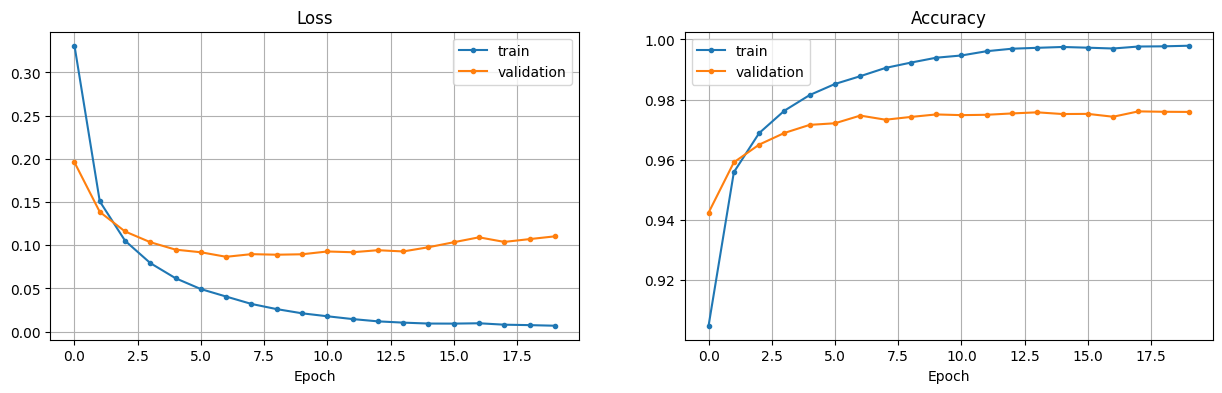

In [ ]:
plot_loss_acc_per_ep(logs["train_losses"], logs["valid_losses"],
                     logs["train_accuracies"], logs["valid_accuracies"])

The model is memorizing patterns too fast (4th epoch divergence) — it seems it will not generalize well beyond that. The data is likely too simple (few pixels).

- Lowering LR: 1e-3 -> 1e-4
- Lowering the number of epochs: 20 -> 10

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

fnn_model = MnistClassifier(
    algorithm="fnn",
    train_dataset=mnist_train,
    batch_size=125,
    epochs=10,
    criterion=nn.CrossEntropyLoss(),
    optimizer=optim.Adam, optim_kwargs={"lr":1e-4},
    random_state=RANDOM_SEED,
    verbose=1,
    device=device,
)

torch.manual_seed(RANDOM_SEED)
logs = fnn_model.train()

Device - cuda
Number of trainable parameters - 101770
Extracting labels for Stratified Split...

--- Running 5-Fold Cross-Validation on cuda ---


Fold 1/5:   0%|          | 0/3840 [00:00<?, ?it/s]

Fold 1/5 | Epoch  1: train_loss=0.8045  val_loss=0.4095  train_acc=0.8100  val_acc=0.8929
Fold 1/5 | Epoch  2: train_loss=0.3529  val_loss=0.3161  train_acc=0.9022  val_acc=0.9108
Fold 1/5 | Epoch  3: train_loss=0.2921  val_loss=0.2762  train_acc=0.9181  val_acc=0.9201
Fold 1/5 | Epoch  4: train_loss=0.2570  val_loss=0.2484  train_acc=0.9275  val_acc=0.9293
Fold 1/5 | Epoch  5: train_loss=0.2302  val_loss=0.2281  train_acc=0.9350  val_acc=0.9357
Fold 1/5 | Epoch  6: train_loss=0.2087  val_loss=0.2088  train_acc=0.9411  val_acc=0.9414
Fold 1/5 | Epoch  7: train_loss=0.1904  val_loss=0.1956  train_acc=0.9467  val_acc=0.9457
Fold 1/5 | Epoch  8: train_loss=0.1751  val_loss=0.1820  train_acc=0.9513  val_acc=0.9495
Fold 1/5 | Epoch  9: train_loss=0.1613  val_loss=0.1720  train_acc=0.9549  val_acc=0.9535
Fold 1/5 | Epoch 10: train_loss=0.1495  val_loss=0.1633  train_acc=0.9580  val_acc=0.9553


Fold 2/5:   0%|          | 0/3840 [00:00<?, ?it/s]

Fold 2/5 | Epoch  1: train_loss=0.8238  val_loss=0.4072  train_acc=0.8108  val_acc=0.8944
Fold 2/5 | Epoch  2: train_loss=0.3554  val_loss=0.3110  train_acc=0.9031  val_acc=0.9132
Fold 2/5 | Epoch  3: train_loss=0.2912  val_loss=0.2708  train_acc=0.9184  val_acc=0.9252
Fold 2/5 | Epoch  4: train_loss=0.2554  val_loss=0.2446  train_acc=0.9279  val_acc=0.9324
Fold 2/5 | Epoch  5: train_loss=0.2283  val_loss=0.2224  train_acc=0.9356  val_acc=0.9359
Fold 2/5 | Epoch  6: train_loss=0.2067  val_loss=0.2060  train_acc=0.9413  val_acc=0.9397
Fold 2/5 | Epoch  7: train_loss=0.1890  val_loss=0.1923  train_acc=0.9468  val_acc=0.9438
Fold 2/5 | Epoch  8: train_loss=0.1741  val_loss=0.1790  train_acc=0.9509  val_acc=0.9479
Fold 2/5 | Epoch  9: train_loss=0.1607  val_loss=0.1689  train_acc=0.9548  val_acc=0.9511
Fold 2/5 | Epoch 10: train_loss=0.1492  val_loss=0.1603  train_acc=0.9582  val_acc=0.9529


Fold 3/5:   0%|          | 0/3840 [00:00<?, ?it/s]

Fold 3/5 | Epoch  1: train_loss=0.8213  val_loss=0.4107  train_acc=0.8120  val_acc=0.8916
Fold 3/5 | Epoch  2: train_loss=0.3565  val_loss=0.3194  train_acc=0.9021  val_acc=0.9088
Fold 3/5 | Epoch  3: train_loss=0.2956  val_loss=0.2798  train_acc=0.9169  val_acc=0.9206
Fold 3/5 | Epoch  4: train_loss=0.2602  val_loss=0.2519  train_acc=0.9264  val_acc=0.9298
Fold 3/5 | Epoch  5: train_loss=0.2341  val_loss=0.2324  train_acc=0.9339  val_acc=0.9341
Fold 3/5 | Epoch  6: train_loss=0.2123  val_loss=0.2122  train_acc=0.9406  val_acc=0.9383
Fold 3/5 | Epoch  7: train_loss=0.1939  val_loss=0.1979  train_acc=0.9454  val_acc=0.9441
Fold 3/5 | Epoch  8: train_loss=0.1787  val_loss=0.1838  train_acc=0.9496  val_acc=0.9467
Fold 3/5 | Epoch  9: train_loss=0.1648  val_loss=0.1745  train_acc=0.9534  val_acc=0.9490
Fold 3/5 | Epoch 10: train_loss=0.1524  val_loss=0.1631  train_acc=0.9569  val_acc=0.9527


Fold 4/5:   0%|          | 0/3840 [00:00<?, ?it/s]

Fold 4/5 | Epoch  1: train_loss=0.8255  val_loss=0.4115  train_acc=0.8079  val_acc=0.8908
Fold 4/5 | Epoch  2: train_loss=0.3475  val_loss=0.3130  train_acc=0.9056  val_acc=0.9113
Fold 4/5 | Epoch  3: train_loss=0.2812  val_loss=0.2734  train_acc=0.9214  val_acc=0.9227
Fold 4/5 | Epoch  4: train_loss=0.2456  val_loss=0.2437  train_acc=0.9304  val_acc=0.9315
Fold 4/5 | Epoch  5: train_loss=0.2194  val_loss=0.2230  train_acc=0.9380  val_acc=0.9381
Fold 4/5 | Epoch  6: train_loss=0.1991  val_loss=0.2068  train_acc=0.9435  val_acc=0.9428
Fold 4/5 | Epoch  7: train_loss=0.1824  val_loss=0.1944  train_acc=0.9477  val_acc=0.9456
Fold 4/5 | Epoch  8: train_loss=0.1682  val_loss=0.1824  train_acc=0.9518  val_acc=0.9478
Fold 4/5 | Epoch  9: train_loss=0.1557  val_loss=0.1713  train_acc=0.9560  val_acc=0.9521
Fold 4/5 | Epoch 10: train_loss=0.1450  val_loss=0.1643  train_acc=0.9591  val_acc=0.9535


Fold 5/5:   0%|          | 0/3840 [00:00<?, ?it/s]

Fold 5/5 | Epoch  1: train_loss=0.8355  val_loss=0.4169  train_acc=0.8020  val_acc=0.8902
Fold 5/5 | Epoch  2: train_loss=0.3511  val_loss=0.3225  train_acc=0.9040  val_acc=0.9099
Fold 5/5 | Epoch  3: train_loss=0.2889  val_loss=0.2805  train_acc=0.9181  val_acc=0.9214
Fold 5/5 | Epoch  4: train_loss=0.2548  val_loss=0.2547  train_acc=0.9285  val_acc=0.9269
Fold 5/5 | Epoch  5: train_loss=0.2287  val_loss=0.2313  train_acc=0.9355  val_acc=0.9344
Fold 5/5 | Epoch  6: train_loss=0.2082  val_loss=0.2147  train_acc=0.9420  val_acc=0.9387
Fold 5/5 | Epoch  7: train_loss=0.1908  val_loss=0.1982  train_acc=0.9467  val_acc=0.9435
Fold 5/5 | Epoch  8: train_loss=0.1756  val_loss=0.1859  train_acc=0.9506  val_acc=0.9450
Fold 5/5 | Epoch  9: train_loss=0.1627  val_loss=0.1769  train_acc=0.9546  val_acc=0.9486
Fold 5/5 | Epoch 10: train_loss=0.1511  val_loss=0.1646  train_acc=0.9576  val_acc=0.9533


Smoothed scores over epochs groupd by folds:
Epoch  1: train_loss=0.8221  val_loss=0.4112  train_acc=0.8085  val_acc=0.8920
Epoch  2: train_loss=0.3527  val_loss=0.3164  train_acc=0.9034  val_acc=0.9108
Epoch  3: train_loss=0.2898  val_loss=0.2762  train_acc=0.9186  val_acc=0.9220
Epoch  4: train_loss=0.2546  val_loss=0.2487  train_acc=0.9281  val_acc=0.9300
Epoch  5: train_loss=0.2282  val_loss=0.2274  train_acc=0.9356  val_acc=0.9356
Epoch  6: train_loss=0.2070  val_loss=0.2097  train_acc=0.9417  val_acc=0.9402
Epoch  7: train_loss=0.1893  val_loss=0.1957  train_acc=0.9467  val_acc=0.9445
Epoch  8: train_loss=0.1743  val_loss=0.1826  train_acc=0.9508  val_acc=0.9474
Epoch  9: train_loss=0.1610  val_loss=0.1727  train_acc=0.9547  val_acc=0.9508
Epoch 10: train_loss=0.1494  val_loss=0.1631  train_acc=0.9580  val_acc=0.9535



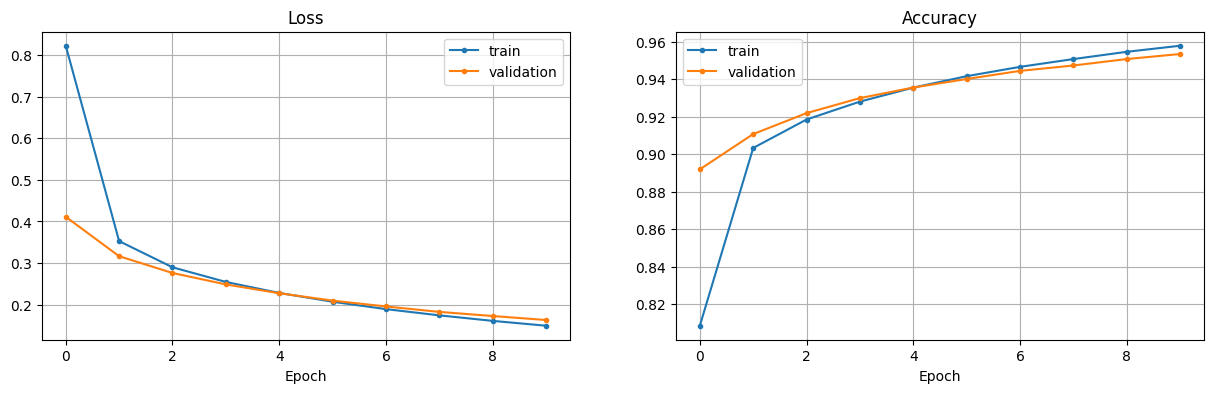

In [ ]:
plot_loss_acc_per_ep(logs["train_losses"], logs["valid_losses"],
                     logs["train_accuracies"], logs["valid_accuracies"])

Lowering LR has caused underfitting (noticeably higher loss, lower accuracy), while the previous caused massive overfitting.
- LR back: 1e-3
- increasing batch size to generalize more: 125 -> 250

Best scores so far:
- val_loss: 0.116
- val_acc: 0.9651

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

fnn_model = MnistClassifier(
    algorithm="fnn",
    train_dataset=mnist_train,
    batch_size=250,
    epochs=10,
    criterion=nn.CrossEntropyLoss(),
    optimizer=optim.Adam, optim_kwargs={"lr":1e-3},
    random_state=RANDOM_SEED,
    verbose=1,
    device=device,
)

torch.manual_seed(RANDOM_SEED)
logs = fnn_model.train()

Device - cuda
Number of trainable parameters - 101770
Extracting labels for Stratified Split...

--- Running 5-Fold Cross-Validation on cuda ---


Fold 1/5:   0%|          | 0/1920 [00:00<?, ?it/s]

Epoch  1: train_loss=0.3975  val_loss=0.2297  train_acc=0.8872  val_acc=0.9335
Epoch  2: train_loss=0.1892  val_loss=0.1805  train_acc=0.9459  val_acc=0.9484
Epoch  3: train_loss=0.1354  val_loss=0.1369  train_acc=0.9610  val_acc=0.9603
Epoch  4: train_loss=0.1048  val_loss=0.1198  train_acc=0.9696  val_acc=0.9650
Epoch  5: train_loss=0.0839  val_loss=0.1175  train_acc=0.9753  val_acc=0.9661
Epoch  6: train_loss=0.0688  val_loss=0.1043  train_acc=0.9800  val_acc=0.9698
Epoch  7: train_loss=0.0576  val_loss=0.0972  train_acc=0.9838  val_acc=0.9724
Epoch  8: train_loss=0.0487  val_loss=0.0978  train_acc=0.9857  val_acc=0.9713
Epoch  9: train_loss=0.0408  val_loss=0.0889  train_acc=0.9887  val_acc=0.9748
Epoch 10: train_loss=0.0344  val_loss=0.0885  train_acc=0.9901  val_acc=0.9756


Fold 2/5:   0%|          | 0/1920 [00:00<?, ?it/s]

Epoch  1: train_loss=0.4057  val_loss=0.2255  train_acc=0.8871  val_acc=0.9344
Epoch  2: train_loss=0.1903  val_loss=0.1694  train_acc=0.9451  val_acc=0.9513
Epoch  3: train_loss=0.1365  val_loss=0.1417  train_acc=0.9608  val_acc=0.9596
Epoch  4: train_loss=0.1038  val_loss=0.1122  train_acc=0.9695  val_acc=0.9669
Epoch  5: train_loss=0.0819  val_loss=0.0989  train_acc=0.9773  val_acc=0.9712
Epoch  6: train_loss=0.0676  val_loss=0.0936  train_acc=0.9807  val_acc=0.9732
Epoch  7: train_loss=0.0548  val_loss=0.0873  train_acc=0.9841  val_acc=0.9741
Epoch  8: train_loss=0.0480  val_loss=0.0892  train_acc=0.9857  val_acc=0.9738
Epoch  9: train_loss=0.0392  val_loss=0.0834  train_acc=0.9888  val_acc=0.9747
Epoch 10: train_loss=0.0331  val_loss=0.0809  train_acc=0.9906  val_acc=0.9762


Fold 3/5:   0%|          | 0/1920 [00:00<?, ?it/s]

Epoch  1: train_loss=0.4099  val_loss=0.2299  train_acc=0.8852  val_acc=0.9307
Epoch  2: train_loss=0.1910  val_loss=0.1686  train_acc=0.9446  val_acc=0.9503
Epoch  3: train_loss=0.1361  val_loss=0.1314  train_acc=0.9601  val_acc=0.9612
Epoch  4: train_loss=0.1030  val_loss=0.1135  train_acc=0.9701  val_acc=0.9657
Epoch  5: train_loss=0.0835  val_loss=0.1089  train_acc=0.9763  val_acc=0.9655
Epoch  6: train_loss=0.0689  val_loss=0.0994  train_acc=0.9803  val_acc=0.9690
Epoch  7: train_loss=0.0559  val_loss=0.0942  train_acc=0.9844  val_acc=0.9709
Epoch  8: train_loss=0.0497  val_loss=0.0876  train_acc=0.9859  val_acc=0.9722
Epoch  9: train_loss=0.0404  val_loss=0.0899  train_acc=0.9886  val_acc=0.9710
Epoch 10: train_loss=0.0348  val_loss=0.0856  train_acc=0.9908  val_acc=0.9741


Fold 4/5:   0%|          | 0/1920 [00:00<?, ?it/s]

Epoch  1: train_loss=0.4030  val_loss=0.2267  train_acc=0.8868  val_acc=0.9363
Epoch  2: train_loss=0.1800  val_loss=0.1627  train_acc=0.9481  val_acc=0.9541
Epoch  3: train_loss=0.1286  val_loss=0.1337  train_acc=0.9627  val_acc=0.9603
Epoch  4: train_loss=0.1007  val_loss=0.1165  train_acc=0.9709  val_acc=0.9647
Epoch  5: train_loss=0.0813  val_loss=0.1116  train_acc=0.9762  val_acc=0.9668
Epoch  6: train_loss=0.0676  val_loss=0.1005  train_acc=0.9804  val_acc=0.9688
Epoch  7: train_loss=0.0557  val_loss=0.1030  train_acc=0.9838  val_acc=0.9683
Epoch  8: train_loss=0.0489  val_loss=0.0900  train_acc=0.9860  val_acc=0.9712
Epoch  9: train_loss=0.0407  val_loss=0.0895  train_acc=0.9888  val_acc=0.9716
Epoch 10: train_loss=0.0342  val_loss=0.0882  train_acc=0.9914  val_acc=0.9734


Fold 5/5:   0%|          | 0/1920 [00:00<?, ?it/s]

Epoch  1: train_loss=0.4034  val_loss=0.2323  train_acc=0.8859  val_acc=0.9317
Epoch  2: train_loss=0.1841  val_loss=0.1667  train_acc=0.9465  val_acc=0.9523
Epoch  3: train_loss=0.1321  val_loss=0.1377  train_acc=0.9619  val_acc=0.9597
Epoch  4: train_loss=0.1034  val_loss=0.1148  train_acc=0.9704  val_acc=0.9657
Epoch  5: train_loss=0.0810  val_loss=0.1074  train_acc=0.9766  val_acc=0.9663
Epoch  6: train_loss=0.0683  val_loss=0.1145  train_acc=0.9801  val_acc=0.9653
Epoch  7: train_loss=0.0555  val_loss=0.0936  train_acc=0.9842  val_acc=0.9713
Epoch  8: train_loss=0.0464  val_loss=0.0920  train_acc=0.9865  val_acc=0.9724
Epoch  9: train_loss=0.0394  val_loss=0.0886  train_acc=0.9894  val_acc=0.9729
Epoch 10: train_loss=0.0329  val_loss=0.0857  train_acc=0.9914  val_acc=0.9734


Smoothed scores over epochs groupd by folds:
Epoch  1: train_loss=0.4039  val_loss=0.2288  train_acc=0.8864  val_acc=0.9333
Epoch  2: train_loss=0.1869  val_loss=0.1696  train_acc=0.9460  val_acc=0.9513
Epoch  3: train_loss=0.1337  val_loss=0.1363  train_acc=0.9613  val_acc=0.9602
Epoch  4: train_loss=0.1031  val_loss=0.1154  train_acc=0.9701  val_acc=0.9656
Epoch  5: train_loss=0.0823  val_loss=0.1089  train_acc=0.9763  val_acc=0.9672
Epoch  6: train_loss=0.0682  val_loss=0.1025  train_acc=0.9803  val_acc=0.9692
Epoch  7: train_loss=0.0559  val_loss=0.0950  train_acc=0.9841  val_acc=0.9714
Epoch  8: train_loss=0.0483  val_loss=0.0913  train_acc=0.9860  val_acc=0.9722
Epoch  9: train_loss=0.0401  val_loss=0.0881  train_acc=0.9889  val_acc=0.9730
Epoch 10: train_loss=0.0339  val_loss=0.0858  train_acc=0.9908  val_acc=0.9746



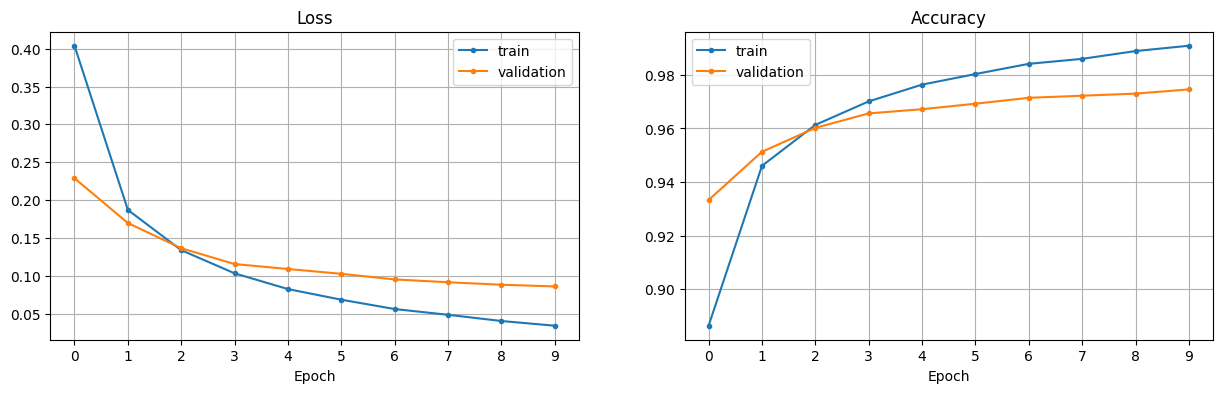

In [ ]:
plot_loss_acc_per_ep(logs["train_losses"], logs["valid_losses"],
                     logs["train_accuracies"], logs["valid_accuracies"])

The loss and accuracy have degraded. The batch size was optimal. The learning rate is clearly a massive contributor, but the 10-time difference 1e-3 and 1e-4 is too much. Trying intermediate versions is considered.
- batch size back: 250 -> 125
- LR 1e-3 -> 3e-3
- epochs 10 -> 7 (to cut down on time)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

fnn_model = MnistClassifier(
    algorithm="fnn",
    train_dataset=mnist_train,
    batch_size=125,
    epochs=7,
    criterion=nn.CrossEntropyLoss(),
    optimizer=optim.Adam, optim_kwargs={"lr":3e-3},
    random_state=RANDOM_SEED,
    verbose=1,
    device=device,
)

torch.manual_seed(RANDOM_SEED)
logs = fnn_model.train()

Device - cuda
Number of trainable parameters - 101770
Extracting labels for Stratified Split...

--- Running 5-Fold Cross-Validation on cuda ---


Fold 1/5:   0%|          | 0/2688 [00:00<?, ?it/s]

Epoch  1: train_loss=0.2545  val_loss=0.1412  train_acc=0.9239  val_acc=0.9568
Epoch  2: train_loss=0.1097  val_loss=0.1114  train_acc=0.9659  val_acc=0.9686
Epoch  3: train_loss=0.0830  val_loss=0.1010  train_acc=0.9741  val_acc=0.9708
Epoch  4: train_loss=0.0615  val_loss=0.1030  train_acc=0.9805  val_acc=0.9693
Epoch  5: train_loss=0.0491  val_loss=0.1313  train_acc=0.9835  val_acc=0.9643
Epoch  6: train_loss=0.0429  val_loss=0.1005  train_acc=0.9863  val_acc=0.9758
Epoch  7: train_loss=0.0334  val_loss=0.1194  train_acc=0.9890  val_acc=0.9718


Fold 2/5:   0%|          | 0/2688 [00:00<?, ?it/s]

Epoch  1: train_loss=0.2572  val_loss=0.1570  train_acc=0.9227  val_acc=0.9504
Epoch  2: train_loss=0.1130  val_loss=0.1011  train_acc=0.9648  val_acc=0.9686
Epoch  3: train_loss=0.0786  val_loss=0.0979  train_acc=0.9760  val_acc=0.9716
Epoch  4: train_loss=0.0645  val_loss=0.1143  train_acc=0.9796  val_acc=0.9702
Epoch  5: train_loss=0.0514  val_loss=0.1212  train_acc=0.9828  val_acc=0.9655
Epoch  6: train_loss=0.0445  val_loss=0.1051  train_acc=0.9853  val_acc=0.9720
Epoch  7: train_loss=0.0361  val_loss=0.1042  train_acc=0.9881  val_acc=0.9751


Fold 3/5:   0%|          | 0/2688 [00:00<?, ?it/s]

Epoch  1: train_loss=0.2572  val_loss=0.1479  train_acc=0.9247  val_acc=0.9533
Epoch  2: train_loss=0.1138  val_loss=0.1232  train_acc=0.9649  val_acc=0.9626
Epoch  3: train_loss=0.0790  val_loss=0.1087  train_acc=0.9756  val_acc=0.9684
Epoch  4: train_loss=0.0646  val_loss=0.1009  train_acc=0.9795  val_acc=0.9702
Epoch  5: train_loss=0.0508  val_loss=0.1060  train_acc=0.9838  val_acc=0.9698
Epoch  6: train_loss=0.0444  val_loss=0.1122  train_acc=0.9856  val_acc=0.9722
Epoch  7: train_loss=0.0364  val_loss=0.1239  train_acc=0.9880  val_acc=0.9682


Fold 4/5:   0%|          | 0/2688 [00:00<?, ?it/s]

Epoch  1: train_loss=0.2557  val_loss=0.1463  train_acc=0.9237  val_acc=0.9546
Epoch  2: train_loss=0.1141  val_loss=0.1213  train_acc=0.9646  val_acc=0.9609
Epoch  3: train_loss=0.0818  val_loss=0.1062  train_acc=0.9744  val_acc=0.9660
Epoch  4: train_loss=0.0638  val_loss=0.1022  train_acc=0.9794  val_acc=0.9695
Epoch  5: train_loss=0.0502  val_loss=0.0982  train_acc=0.9834  val_acc=0.9726
Epoch  6: train_loss=0.0465  val_loss=0.1211  train_acc=0.9845  val_acc=0.9673
Epoch  7: train_loss=0.0392  val_loss=0.1214  train_acc=0.9869  val_acc=0.9660


Fold 5/5:   0%|          | 0/2688 [00:00<?, ?it/s]

Epoch  1: train_loss=0.2640  val_loss=0.1551  train_acc=0.9202  val_acc=0.9542
Epoch  2: train_loss=0.1123  val_loss=0.1365  train_acc=0.9663  val_acc=0.9581
Epoch  3: train_loss=0.0822  val_loss=0.1225  train_acc=0.9742  val_acc=0.9651
Epoch  4: train_loss=0.0644  val_loss=0.1013  train_acc=0.9794  val_acc=0.9712
Epoch  5: train_loss=0.0531  val_loss=0.1259  train_acc=0.9820  val_acc=0.9673
Epoch  6: train_loss=0.0482  val_loss=0.1090  train_acc=0.9847  val_acc=0.9725
Epoch  7: train_loss=0.0424  val_loss=0.1172  train_acc=0.9861  val_acc=0.9715


Smoothed scores over epochs groupd by folds:
Epoch  1: train_loss=0.2577  val_loss=0.1495  train_acc=0.9230  val_acc=0.9539
Epoch  2: train_loss=0.1126  val_loss=0.1187  train_acc=0.9653  val_acc=0.9638
Epoch  3: train_loss=0.0809  val_loss=0.1073  train_acc=0.9748  val_acc=0.9684
Epoch  4: train_loss=0.0638  val_loss=0.1043  train_acc=0.9797  val_acc=0.9701
Epoch  5: train_loss=0.0509  val_loss=0.1165  train_acc=0.9831  val_acc=0.9679
Epoch  6: train_loss=0.0453  val_loss=0.1096  train_acc=0.9853  val_acc=0.9720
Epoch  7: train_loss=0.0375  val_loss=0.1172  train_acc=0.9876  val_acc=0.9705



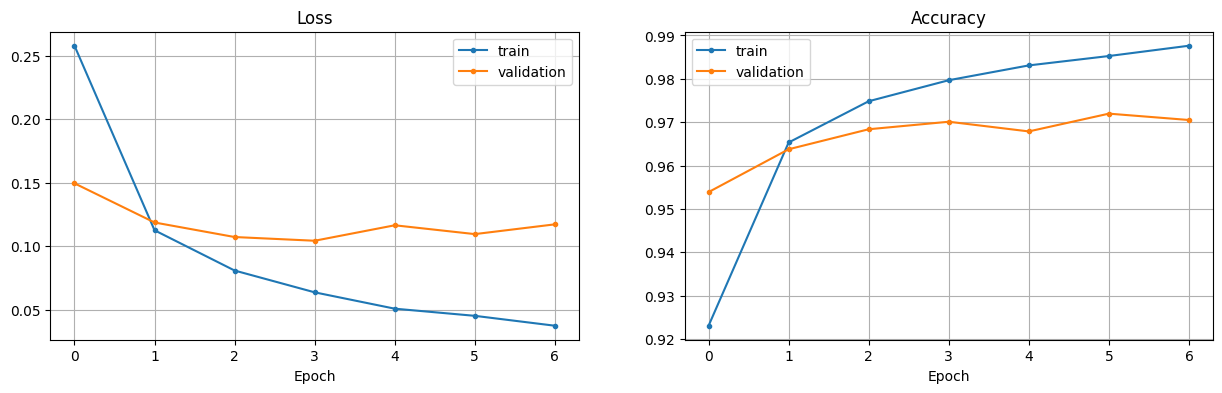

In [ ]:
plot_loss_acc_per_ep(logs["train_losses"], logs["valid_losses"],
                     logs["train_accuracies"], logs["valid_accuracies"])

The scores haven't surpassed the best ones. LR changes the divergence vastly. Trying the last intermediate LR value:
- LR 3e-3 -> 2e-3

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

fnn_model = MnistClassifier(
    algorithm="fnn",
    train_dataset=mnist_train,
    batch_size=125,
    epochs=7,
    criterion=nn.CrossEntropyLoss(),
    optimizer=optim.Adam, optim_kwargs={"lr":2e-3},
    random_state=RANDOM_SEED,
    verbose=1,
    device=device,
)

torch.manual_seed(RANDOM_SEED)
logs = fnn_model.train()

Device - cuda
Number of trainable parameters - 101770
Extracting labels for Stratified Split...

--- Running 5-Fold Cross-Validation on cuda ---


Fold 1/5:   0%|          | 0/2688 [00:00<?, ?it/s]

Epoch  1: train_loss=0.2674  val_loss=0.1552  train_acc=0.9201  val_acc=0.9532
Epoch  2: train_loss=0.1145  val_loss=0.1089  train_acc=0.9654  val_acc=0.9669
Epoch  3: train_loss=0.0816  val_loss=0.0984  train_acc=0.9747  val_acc=0.9708
Epoch  4: train_loss=0.0604  val_loss=0.0888  train_acc=0.9808  val_acc=0.9732
Epoch  5: train_loss=0.0469  val_loss=0.1048  train_acc=0.9845  val_acc=0.9697
Epoch  6: train_loss=0.0375  val_loss=0.1008  train_acc=0.9874  val_acc=0.9715
Epoch  7: train_loss=0.0325  val_loss=0.0913  train_acc=0.9891  val_acc=0.9753


Fold 2/5:   0%|          | 0/2688 [00:00<?, ?it/s]

Epoch  1: train_loss=0.2732  val_loss=0.1632  train_acc=0.9190  val_acc=0.9505
Epoch  2: train_loss=0.1198  val_loss=0.1074  train_acc=0.9637  val_acc=0.9662
Epoch  3: train_loss=0.0810  val_loss=0.0956  train_acc=0.9753  val_acc=0.9709
Epoch  4: train_loss=0.0624  val_loss=0.1000  train_acc=0.9803  val_acc=0.9718
Epoch  5: train_loss=0.0486  val_loss=0.0967  train_acc=0.9843  val_acc=0.9718
Epoch  6: train_loss=0.0387  val_loss=0.0865  train_acc=0.9878  val_acc=0.9754
Epoch  7: train_loss=0.0317  val_loss=0.0854  train_acc=0.9892  val_acc=0.9773


Fold 3/5:   0%|          | 0/2688 [00:00<?, ?it/s]

Epoch  1: train_loss=0.2811  val_loss=0.1526  train_acc=0.9172  val_acc=0.9542
Epoch  2: train_loss=0.1207  val_loss=0.1116  train_acc=0.9634  val_acc=0.9664
Epoch  3: train_loss=0.0813  val_loss=0.1079  train_acc=0.9745  val_acc=0.9663
Epoch  4: train_loss=0.0607  val_loss=0.0939  train_acc=0.9814  val_acc=0.9725
Epoch  5: train_loss=0.0473  val_loss=0.0885  train_acc=0.9845  val_acc=0.9734
Epoch  6: train_loss=0.0388  val_loss=0.1046  train_acc=0.9872  val_acc=0.9719
Epoch  7: train_loss=0.0325  val_loss=0.0906  train_acc=0.9893  val_acc=0.9750


Fold 4/5:   0%|          | 0/2688 [00:00<?, ?it/s]

Epoch  1: train_loss=0.2711  val_loss=0.1569  train_acc=0.9202  val_acc=0.9528
Epoch  2: train_loss=0.1180  val_loss=0.1138  train_acc=0.9647  val_acc=0.9647
Epoch  3: train_loss=0.0814  val_loss=0.0974  train_acc=0.9754  val_acc=0.9699
Epoch  4: train_loss=0.0622  val_loss=0.0999  train_acc=0.9806  val_acc=0.9692
Epoch  5: train_loss=0.0488  val_loss=0.0939  train_acc=0.9844  val_acc=0.9717
Epoch  6: train_loss=0.0391  val_loss=0.1038  train_acc=0.9876  val_acc=0.9712
Epoch  7: train_loss=0.0323  val_loss=0.0934  train_acc=0.9890  val_acc=0.9726


Fold 5/5:   0%|          | 0/2688 [00:00<?, ?it/s]

Epoch  1: train_loss=0.2808  val_loss=0.1622  train_acc=0.9163  val_acc=0.9531
Epoch  2: train_loss=0.1190  val_loss=0.1288  train_acc=0.9646  val_acc=0.9600
Epoch  3: train_loss=0.0845  val_loss=0.1017  train_acc=0.9738  val_acc=0.9692
Epoch  4: train_loss=0.0628  val_loss=0.0964  train_acc=0.9803  val_acc=0.9720
Epoch  5: train_loss=0.0492  val_loss=0.1127  train_acc=0.9846  val_acc=0.9677
Epoch  6: train_loss=0.0444  val_loss=0.1051  train_acc=0.9855  val_acc=0.9715
Epoch  7: train_loss=0.0331  val_loss=0.0985  train_acc=0.9894  val_acc=0.9735


Smoothed scores over epochs groupd by folds:
Epoch  1: train_loss=0.2747  val_loss=0.1580  train_acc=0.9185  val_acc=0.9527
Epoch  2: train_loss=0.1184  val_loss=0.1141  train_acc=0.9644  val_acc=0.9648
Epoch  3: train_loss=0.0820  val_loss=0.1002  train_acc=0.9747  val_acc=0.9694
Epoch  4: train_loss=0.0617  val_loss=0.0958  train_acc=0.9807  val_acc=0.9717
Epoch  5: train_loss=0.0482  val_loss=0.0993  train_acc=0.9845  val_acc=0.9709
Epoch  6: train_loss=0.0397  val_loss=0.1001  train_acc=0.9871  val_acc=0.9723
Epoch  7: train_loss=0.0324  val_loss=0.0918  train_acc=0.9892  val_acc=0.9747



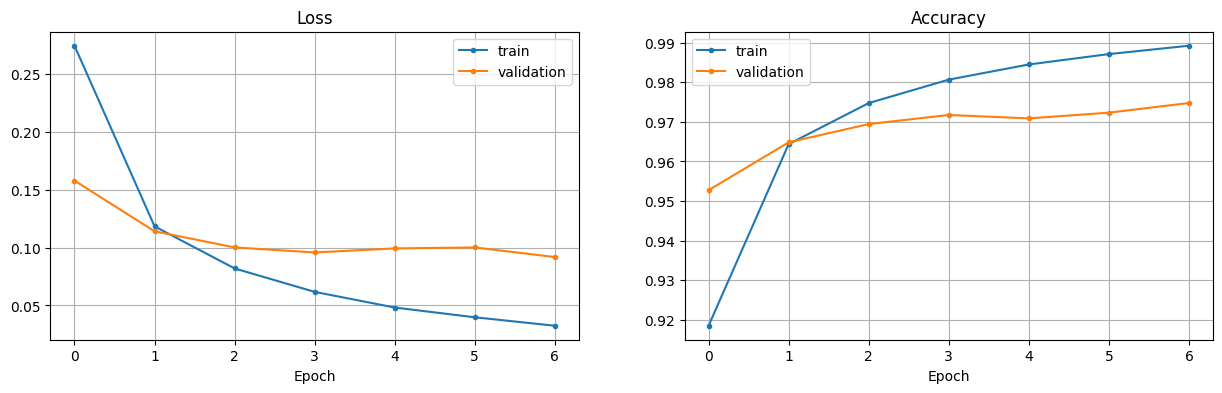

In [ ]:
plot_loss_acc_per_ep(logs["train_losses"], logs["valid_losses"],
                     logs["train_accuracies"], logs["valid_accuracies"])

The very first fit has remained the best. The training log:

| Epoch (Best) | Batch Size | LR  | Train Loss | Val Loss | Train Acc | Val Acc |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| 3 | 125 | 1e-3 | 0.1052 | 0.1160 | 0.9689 | 0.9651 |
| 3 | 250 | 1e-3 | 0.1337 | 0.1363 | 0.9613 | 0.9602 |
| 2 | 125 | 3e-3 | 0.1126 | 0.1187 | 0.9653 | 0.9638 |
| 2 | 125 | 2e-3 | 0.1184 | 0.1141 | 0.9644 | 0.9648 |
| 5 | 125 | 1e-4 | 0.2282 | 0.2274 | 0.9356 | 0.9356 |
| 5 | 60  | 1e-4 | 0.1836 | 0.1864 | 0.9478 | 0.9475 |
| 4 | 30  | 1e-4 | 0.1768 | 0.1760 | 0.9500 | 0.9501 |


### Best final model final fit and save

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

fnn_model = MnistClassifier(
    algorithm="fnn",
    train_dataset=mnist_train,
    batch_size=125,
    epochs=3,
    criterion=nn.CrossEntropyLoss(),
    optimizer=optim.Adam, optim_kwargs={"lr":1e-3},
    random_state=RANDOM_SEED,
    verbose=1,
    device=device,
)

torch.manual_seed(RANDOM_SEED)
fnn_model.final_fit()

Device - cuda
Number of trainable parameters - 101770

--- Fitting Final Model on Full Train Set ---


Final fit:   0%|          | 0/1440 [00:00<?, ?it/s]

Epoch  1: train_loss=0.3005
Epoch  2: train_loss=0.1314
Epoch  3: train_loss=0.0913


For deeper networks, the right way to save is to save their state dictionary - a plain dict of `{layer_name: weight_tensor}`, the models themselves are heavy.

In [ ]:
torch.save(fnn_model.model.model.state_dict(), "ffn_mnist.pt")

To load, we rebuild the architecture first, then pour the weights in

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

final_fnn_model = MnistClassifier(
    algorithm="fnn",
    train_dataset=mnist_train,
    batch_size=125,
    epochs=3,
    criterion=nn.CrossEntropyLoss(),
    optimizer=optim.Adam, optim_kwargs={"lr":1e-3},
    random_state=RANDOM_SEED,
    verbose=1,
    device=device,
)

model = nn.Sequential(                       # must match the saved architecture exactly
    nn.Flatten(),
    nn.Linear(28*28, 128),
    nn.ReLU(),
    nn.Linear(128, 10),
).to(device)
model.load_state_dict(torch.load("ffn_mnist.pt", map_location="cpu"))

# artificially imitating model training (should have a separate method for it)
# def load(self, path):
#     self.model = self._build_model().to(self.device)
#     self.model.load_state_dict(torch.load(path, map_location=self.device))
#     self.model.eval()
#     self.fitted = True

final_fnn_model.model.model = model
final_fnn_model.model.fitted = True

## Evaluate on test

In [ ]:
y_hat, y = fnn_model.predict(mnist_test)

              precision    recall  f1-score   support

           0     0.9691    0.9908    0.9798       980
           1     0.9902    0.9824    0.9863      1135
           2     0.9805    0.9767    0.9786      1032
           3     0.9629    0.9752    0.9690      1010
           4     0.9706    0.9745    0.9726       982
           5     0.9828    0.9619    0.9722       892
           6     0.9671    0.9823    0.9746       958
           7     0.9573    0.9805    0.9688      1028
           8     0.9729    0.9600    0.9664       974
           9     0.9826    0.9495    0.9657      1009

    accuracy                         0.9736     10000
   macro avg     0.9736    0.9734    0.9734     10000
weighted avg     0.9737    0.9736    0.9736     10000



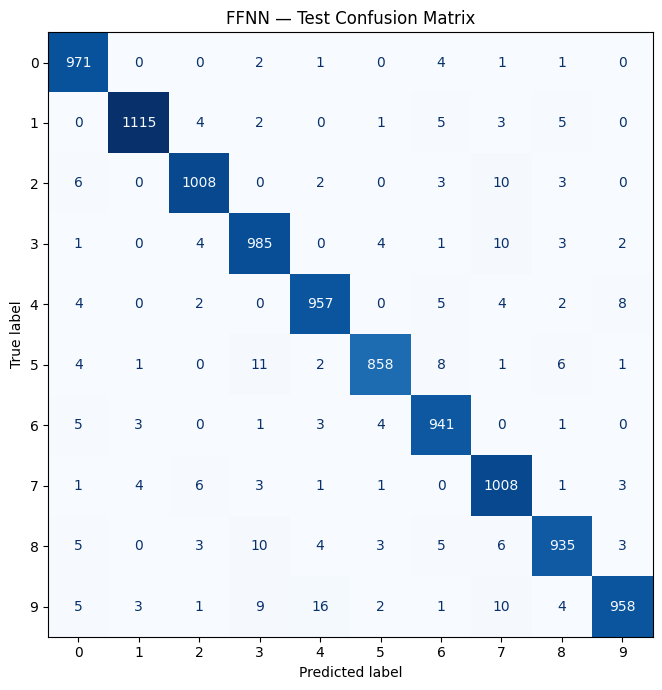

In [ ]:
# 1. --- Per-class metrics ---
print(classification_report(y, y_hat, digits=4))

# 2. --- Confusion matrix: where the errors actually are ---
cm = confusion_matrix(y, y_hat)
fig, ax = plt.subplots(figsize=(7, 7))
ConfusionMatrixDisplay(cm, display_labels=range(10)).plot(
    ax=ax, cmap="Blues", colorbar=False, values_format="d",
)
ax.set_title("FFNN — Test Confusion Matrix")
plt.tight_layout()
plt.show()

## Conclusion

The FFN has surpassed the baseline (Logistic Regression). The best set of parameters and metrics for FFN:

| Epoch (Best) | Batch Size | LR  | Train Loss | Val Loss | Train Acc | Val Acc |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| 3 | 125 | 1e-3 | 0.1052 | 0.1160 | 0.9689 | 0.9651 |

Test metrics:
- `Accuracy`: 0.9736 
- `F1`: 0.9734

Cross-validation and test numbers are close and test is higher. It confirms the pipeline didn't leak and the model generalizes.

Support in classification report confirms the test set is balanced and the report is reliable:
- The class `9` has the lowest recall (`0.9495`), it is very often confused with `4`, `7` and `3`.
- Similarly, `2` is confused with `7`, `3` with `7`, `5` with `3`, `8` with `3`.
- The class `3` is often the culprit. We might want to increase their variety by introducing augmentations.